# Thesis:
### Nepal's dependence on remittances has surged far beyond that of its South Asian neighbors, and while it has helped improve living standards, it has contributed little to the growth of the domestic economy. ###

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
hdi = pd.read_csv('data/human-development-index.csv')
hdi.head()

,Entity,Code,Year,Human Development Index,World region according to OWID
0,Afghanistan,AFG,1990,0.285,Asia
1,Afghanistan,AFG,1991,0.291,Asia
2,Afghanistan,AFG,1992,0.301,Asia
3,Afghanistan,AFG,1993,0.311,Asia
4,Afghanistan,AFG,1994,0.305,Asia


In [4]:
df = pd.read_excel('data/wdi2.xlsx')

In [5]:
df.head()

,Series Name,Series Code,Country Name,Country Code,1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],1994 [YR1994],1995 [YR1995],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Bangladesh,BGD,2.464894,2.485233,2.875409,3.037325,3.408134,3.167296,...,5.118036,4.596677,4.843823,5.228418,5.816268,5.334378,4.673765,5.045557,6.114947,7.424418
1,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Bhutan,BTN,..,..,..,..,..,..,...,1.456771,1.665298,2.250908,2.071101,3.39498,2.649783,3.310867,3.582516,3.275087,..
2,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,India,IND,0.742647,1.217714,1.005324,1.261311,1.789534,1.727257,...,2.734201,2.601088,2.914992,2.938775,3.108553,2.821835,3.422273,3.414146,3.660765,3.809632
3,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Maldives,MDV,0.790536,0.736507,0.561648,0.403203,0.610531,0.592943,...,0.086752,0.083402,0.078045,0.077343,0.125253,0.09296,0.082997,0.081304,0.080043,..
4,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Nepal,NPL,..,..,..,1.497937,1.23239,1.2911,...,26.960565,23.913544,25.02642,24.11637,24.250246,22.277579,22.853297,26.223114,25.992486,..


## Data Cleaning ##

In [6]:
hdi_df = hdi[hdi['Entity'].isin(['Nepal','India','Bhutan','Pakistan','Bangladesh']) & ~(hdi['Year'].isin([1990,1991,1992]))]
hdi_df.head() #this hdi was added later after cleaning the world bank data

,Entity,Code,Year,Human Development Index,World region according to OWID
486,Bangladesh,BGD,1993,0.419,Asia
487,Bangladesh,BGD,1994,0.426,Asia
488,Bangladesh,BGD,1995,0.434,Asia
489,Bangladesh,BGD,1996,0.442,Asia
490,Bangladesh,BGD,1997,0.451,Asia


In [7]:
hdi_df = hdi_df.rename(columns={'Entity':'Country Name','Human Development Index': 'HDI'})

In [8]:
# sns.boxplot(x= hdi_df.loc[hdi_df['Country Name'] == 'Bhutan', 'HDI'])
# print(hdi_df[hdi_df['Country Name'] == 'Bhutan']['HDI'].skew())

In [9]:
df.shape

(64, 40)

In [10]:
df['Series Name'].unique()

<ArrowStringArray>
[                          'Personal remittances, received (% of GDP)',
                             'Life expectancy at birth, total (years)',
                     'Mortality rate, under-5 (per 1,000 live births)',
 'Poverty headcount ratio at national poverty lines (% of population)',
                                    'GDP per capita growth (annual %)',
                            'Exports of goods and services (% of GDP)',
                               'Manufacturing, value added (% of GDP)',
                   'Foreign direct investment, net inflows (% of GDP)']
Length: 8, dtype: str

In [11]:
#looked at the spreadsheet no data was recorded so dropping these:
df.columns
df = df.drop(columns= ['1990 [YR1990]', '1991 [YR1991]', '1992 [YR1992]','2025 [YR2025]'])

In [12]:
long_df = df.melt(
    id_vars=['Series Name', 'Series Code', 'Country Name', 'Country Code'],
    var_name='Year'
)


In [13]:
long_df.head()

,Series Name,Series Code,Country Name,Country Code,Year,value
0,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Bangladesh,BGD,1993 [YR1993],3.037325
1,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Bhutan,BTN,1993 [YR1993],..
2,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,India,IND,1993 [YR1993],1.261311
3,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Maldives,MDV,1993 [YR1993],0.403203
4,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Nepal,NPL,1993 [YR1993],1.497937


In [14]:
long_df.dtypes

Series Name        str
Series Code        str
Country Name       str
Country Code       str
Year               str
value           object
dtype: object

In [15]:
long_df['Year'] = long_df['Year'].str.extract(r'(\d{4})').astype(int)
long_df['value'] = pd.to_numeric(long_df['value'], errors= 'coerce')

In [16]:
long_df.head()
long_df.shape
long_df.dtypes
long_df.info()
long_df['Country Name'].unique()
long_df['Series Name'].unique()
print('number of null values: ',long_df['value'].isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2048 entries, 0 to 2047
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Series Name   2048 non-null   str    
 1   Series Code   2048 non-null   str    
 2   Country Name  2048 non-null   str    
 3   Country Code  2048 non-null   str    
 4   Year          2048 non-null   int64  
 5   value         1690 non-null   float64
dtypes: float64(1), int64(1), str(4)
memory usage: 235.9 KB
number of null values:  358


In [17]:
missingvals = long_df.loc[(long_df['value'].isna()), 'Series Name'].value_counts()
missingvals

Series Name
Poverty headcount ratio at national poverty lines (% of population)    228
Exports of goods and services (% of GDP)                                53
Personal remittances, received (% of GDP)                               32
Manufacturing, value added (% of GDP)                                   19
Foreign direct investment, net inflows (% of GDP)                       18
GDP per capita growth (annual %)                                         8
Name: count, dtype: int64

In [18]:
PovertySeries = long_df.loc[long_df['Series Name'] == 'Poverty headcount ratio at national poverty lines (% of population)','Series Name']
PovertySeries.shape

(256,)

In [19]:
temp = long_df.loc[long_df['Series Name'] == 'Poverty headcount ratio at national poverty lines (% of population)',['Series Name','Country Name','value']]
temp[temp['Country Name']== 'Nepal'].notna().sum()

Series Name     32
Country Name    32
value            1
dtype: int64

In [20]:
long_df = long_df[long_df['Series Name'] != 'Poverty headcount ratio at national poverty lines (% of population)']

In [21]:
long_df['Series Name'].unique()

<ArrowStringArray>
[        'Personal remittances, received (% of GDP)',
           'Life expectancy at birth, total (years)',
   'Mortality rate, under-5 (per 1,000 live births)',
                  'GDP per capita growth (annual %)',
          'Exports of goods and services (% of GDP)',
             'Manufacturing, value added (% of GDP)',
 'Foreign direct investment, net inflows (% of GDP)']
Length: 7, dtype: str

In [22]:
nanexport= (long_df['Series Name'] == 'Exports of goods and services (% of GDP)') & (long_df['value'].isna())
long_df.loc[nanexport, 'Country Name'].value_counts()

Country Name
Afghanistan    27
Maldives       21
Sri Lanka       5
Name: count, dtype: int64

In [23]:
#actually realized it's safe to exclue both afghanistan,maldives and sri lanka as they are more than 2k km away from nepal
long_df = long_df[~long_df['Country Name'].isin(['Afghanistan','Maldives','Sri Lanka'])]
long_df['Country Name'].unique()

<ArrowStringArray>
['Bangladesh', 'Bhutan', 'India', 'Nepal', 'Pakistan']
Length: 5, dtype: str

In [24]:
long_df['value'].isna().sum()
long_df.loc[long_df['value'].isna(), 'Series Name'].value_counts()

Series Name
Personal remittances, received (% of GDP)            13
Foreign direct investment, net inflows (% of GDP)     8
Name: count, dtype: int64

In [25]:
#finding which countries have missing remittance entry and FDI, net inflows
long_df.loc[(long_df['Series Name'] == 'Personal remittances, received (% of GDP)' ) & long_df['value'].isna(),'Country Name'].value_counts()
long_df.loc[(long_df['Series Name'] == 'Personal remittances, received (% of GDP)' ) & long_df['value'].isna(),['Year','Country Name']]

,Year,Country Name
1,1993,Bhutan
65,1994,Bhutan
129,1995,Bhutan
193,1996,Bhutan
257,1997,Bhutan
321,1998,Bhutan
385,1999,Bhutan
449,2000,Bhutan
513,2001,Bhutan
577,2002,Bhutan


In [26]:
#finding which countries have missing fdi inflows:
long_df.loc[(long_df['Series Name'] == 'Foreign direct investment, net inflows (% of GDP)' ) & long_df['value'].isna(),'Country Name'].value_counts()

Country Name
Bhutan    5
Nepal     3
Name: count, dtype: int64

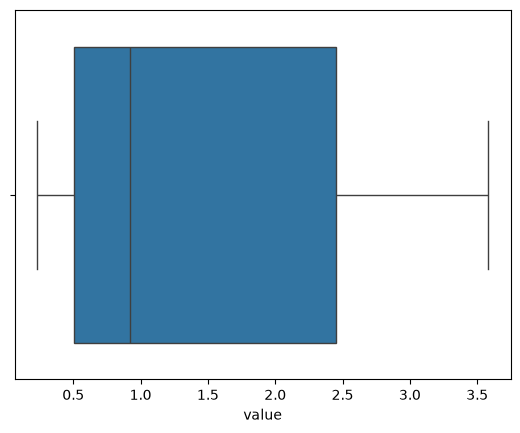

0.579103081196997


In [27]:
#plotting to see the distribution of remittance received for bhutan
sns.boxplot(x =long_df.loc[(long_df['Country Name'] == 'Bhutan') & (long_df['Series Name'] == 'Personal remittances, received (% of GDP)'),'value'])
plt.show()
print(long_df.loc[(long_df['Country Name'] == 'Bhutan') & (long_df['Series Name'] == 'Personal remittances, received (% of GDP)'),'value'].skew())

In [28]:
regress_df = long_df.dropna()


In [29]:
regress_df.head()

,Series Name,Series Code,Country Name,Country Code,Year,value
0,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Bangladesh,BGD,1993,3.037325
2,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,India,IND,1993,1.261311
4,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Nepal,NPL,1993,1.497937
7,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Pakistan,PAK,1993,2.791502
8,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,Bangladesh,BGD,1993,57.073000


In [30]:
bhutan_df = long_df[long_df['Country Name'] == 'Bhutan'].pivot_table(
    index='Year',
    columns='Series Name',
    values='value'
)

bhutan_df.head()

Series Name,Exports of goods and services (% of GDP),"Foreign direct investment, net inflows (% of GDP)",GDP per capita growth (annual %),"Life expectancy at birth, total (years)","Manufacturing, value added (% of GDP)","Mortality rate, under-5 (per 1,000 live births)","Personal remittances, received (% of GDP)"
Year,,,,,,,
1993,32.859303,NaN,6.233891,57.906,9.215876,112.1,NaN
1994,30.875963,NaN,4.984816,58.395,9.508232,107.0,NaN
1995,39.405831,0.017212,8.345746,59.277,10.755804,102.0,NaN
1996,37.006822,0.461424,5.412245,59.982,11.707055,96.9,NaN
1997,37.301470,-0.198734,3.504183,60.639,10.220479,92.0,NaN


In [31]:
nepal_df = long_df[long_df['Country Name'] == 'Nepal'].pivot_table(
    index= 'Year',
    columns= 'Series Name',
    values= 'value'
)

nepal_df.head()

Series Name,Exports of goods and services (% of GDP),"Foreign direct investment, net inflows (% of GDP)",GDP per capita growth (annual %),"Life expectancy at birth, total (years)","Manufacturing, value added (% of GDP)","Mortality rate, under-5 (per 1,000 live births)","Personal remittances, received (% of GDP)"
Year,,,,,,,
1993,18.432964,NaN,1.052829,57.597,8.320716,117.7,1.497937
1994,18.993938,NaN,5.538591,58.631,8.963126,111.4,1.232390
1995,24.973159,NaN,1.012793,59.323,8.922094,105.3,1.291100
1996,22.817575,0.423749,3.029115,60.044,9.025643,99.5,0.976652
1997,26.327835,0.468752,2.887868,60.823,8.846649,94.0,1.005512


In [32]:
(bhutan_df.corr(numeric_only= True))['Personal remittances, received (% of GDP)'].sort_values(ascending= False)#checking correlation of other metrics with remittance received
# I will choose life expectancy at birth, exports of goods and servies to predict remittance.

Series Name
Personal remittances, received (% of GDP)            1.000000
Life expectancy at birth, total (years)              0.896372
Manufacturing, value added (% of GDP)               -0.211338
GDP per capita growth (annual %)                    -0.448322
Foreign direct investment, net inflows (% of GDP)   -0.508763
Exports of goods and services (% of GDP)            -0.766892
Mortality rate, under-5 (per 1,000 live births)     -0.893571
Name: Personal remittances, received (% of GDP), dtype: float64

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [34]:
target = 'Personal remittances, received (% of GDP)'
feature = 'Life expectancy at birth, total (years)'

clean_df_bhutan = bhutan_df.dropna()
X_known = np.array(clean_df_bhutan[[feature]].values)
y_known = np.array(clean_df_bhutan[target].values)

modelremit = LinearRegression()
modelremit.fit(X_known,y_known)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
r2_score(y_known, modelremit.predict(X_known))

0.8034832165960456

In [36]:
#predicting the missing remittance values of Bhutan:
missing_remit = bhutan_df[bhutan_df[target].isna() & bhutan_df[feature].notna()]

X_missing = np.array(missing_remit[[feature]].values)
predicted_remit = modelremit.predict(X_missing)

predicted_years = missing_remit.index

mask = (
    (long_df['Country Name'] == 'Bhutan') &
    (long_df['Series Name'] == target) &
    (long_df['Year'].isin(predicted_years))
)

long_df.loc[mask, 'value'] = predicted_remit

In [37]:
long_df[(long_df['Country Name']=='Bhutan') & (long_df['Series Name']==target)].sort_values('Year');

In [38]:
(nepal_df.corr(numeric_only= True))['Foreign direct investment, net inflows (% of GDP)'].sort_values(ascending= False) #fdi for nepal

Series Name
Foreign direct investment, net inflows (% of GDP)    1.000000
Personal remittances, received (% of GDP)            0.200117
Life expectancy at birth, total (years)              0.187342
GDP per capita growth (annual %)                     0.186118
Mortality rate, under-5 (per 1,000 live births)     -0.212252
Exports of goods and services (% of GDP)            -0.277868
Manufacturing, value added (% of GDP)               -0.380589
Name: Foreign direct investment, net inflows (% of GDP), dtype: float64

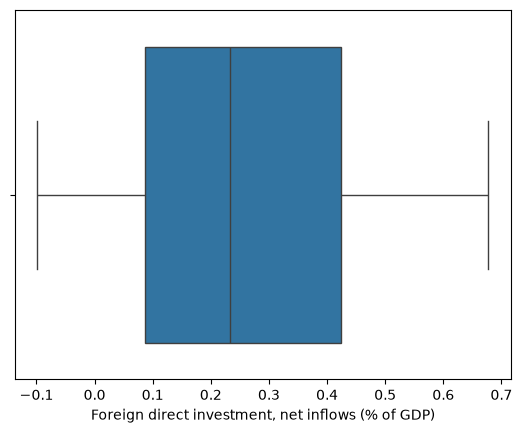

0.11028131030346874


In [39]:
#Distribution of fdi data in nepal
sns.boxplot(data = nepal_df, x='Foreign direct investment, net inflows (% of GDP)')
plt.show()

print(nepal_df['Foreign direct investment, net inflows (% of GDP)'].skew())

In [40]:
#since the data isn't skewed I will use mean
predicted_fdi_nepal = nepal_df['Foreign direct investment, net inflows (% of GDP)'].mean() #oh it igonre the NaNs

long_df.loc[(long_df['Country Name'] == 'Nepal') & (long_df['Series Name'] == 'Foreign direct investment, net inflows (% of GDP)'), 'value'] = predicted_fdi_nepal

In [41]:
(bhutan_df.corr(numeric_only= True))['Foreign direct investment, net inflows (% of GDP)'].sort_values(ascending= False)#fdi for bhutan

Series Name
Foreign direct investment, net inflows (% of GDP)    1.000000
GDP per capita growth (annual %)                     0.597150
Exports of goods and services (% of GDP)             0.525127
Mortality rate, under-5 (per 1,000 live births)     -0.008621
Life expectancy at birth, total (years)             -0.016937
Manufacturing, value added (% of GDP)               -0.054082
Personal remittances, received (% of GDP)           -0.508763
Name: Foreign direct investment, net inflows (% of GDP), dtype: float64

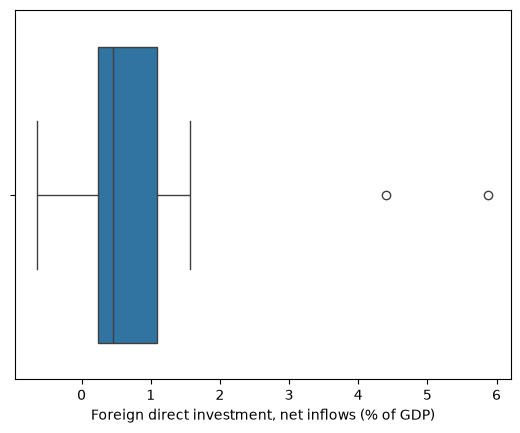

2.76957485164082


In [42]:
fdi_mask = 'Foreign direct investment, net inflows (% of GDP)'
sns.boxplot(data= bhutan_df, x = fdi_mask)
plt.show()

print(bhutan_df[fdi_mask].skew())

In [43]:
# it is too skewed so using median
predicted_fdi_bhutan = bhutan_df[fdi_mask].median()

long_df.loc[(long_df['Country Name'] == 'Bhutan') & (long_df['Series Name'] == fdi_mask), 'value'] = predicted_fdi_bhutan

In [44]:
long_df.isna().sum()

Series Name     0
Series Code     0
Country Name    0
Country Code    0
Year            0
value           0
dtype: int64

In [45]:
long_df.head()

,Series Name,Series Code,Country Name,Country Code,Year,value
0,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Bangladesh,BGD,1993,3.037325
1,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Bhutan,BTN,1993,-5.142658
2,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,India,IND,1993,1.261311
4,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Nepal,NPL,1993,1.497937
7,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,Pakistan,PAK,1993,2.791502


## Plots ##

In [46]:
remit_df = long_df[long_df['Series Name'] == 'Personal remittances, received (% of GDP)']
remit_df.head();

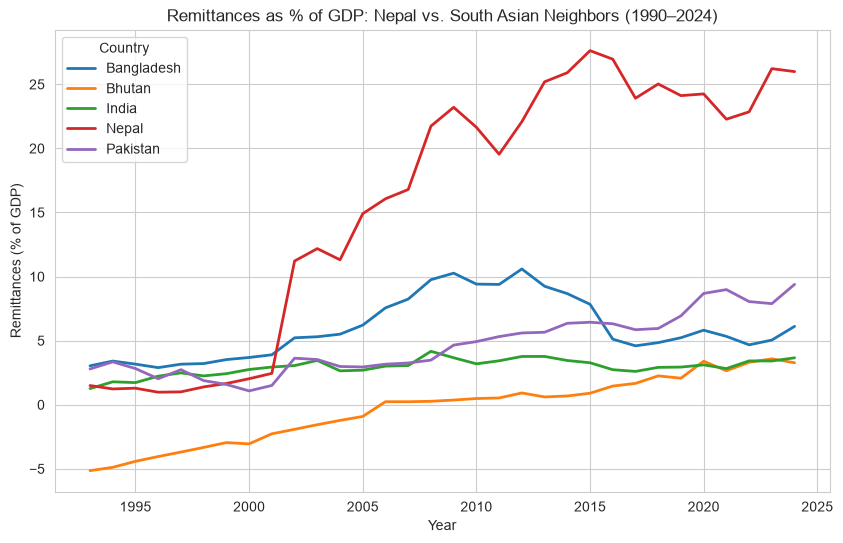

In [47]:
#plotting the remittance in contrast to other countries for Nepal:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.lineplot(data=remit_df, x='Year', y='value', hue='Country Name', linewidth=2)
plt.title("Remittances as % of GDP: Nepal vs. South Asian Neighbors (1990–2024)")
plt.xlabel("Year")
plt.ylabel("Remittances (% of GDP)")
plt.legend(title='Country')
plt.show()

In [48]:
long_df['Year'].max()

np.int64(2024)

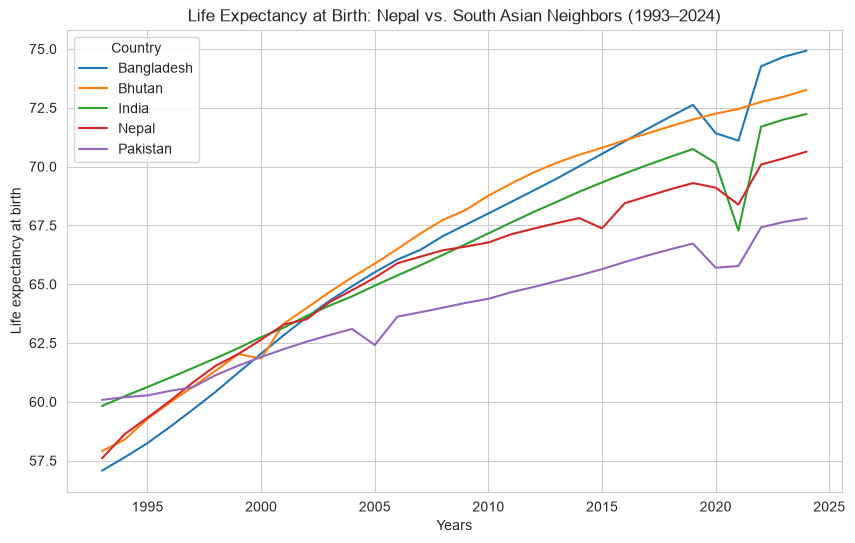

In [49]:
#showing the trend in quality of life in comparision to neighbors:
lifeExp_df = long_df[long_df['Series Name'] == 'Life expectancy at birth, total (years)']

sns.set_style(style= 'whitegrid')
plt.figure(figsize= (10,6))
sns.lineplot(data=lifeExp_df, x = 'Year', y = 'value', hue= 'Country Name') 
plt.title('Life Expectancy at Birth: Nepal vs. South Asian Neighbors (1993–2024)')
plt.xlabel('Years')
plt.ylabel('Life expectancy at birth')
plt.legend(title = 'Country')
plt.show()

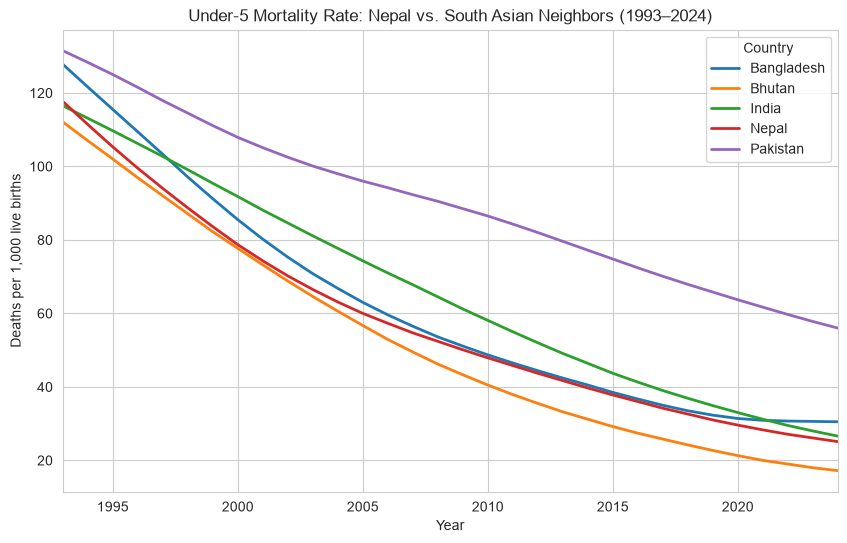

In [50]:
#plotting the Mortality under 5
mortality_df = long_df[long_df['Series Name'] == 'Mortality rate, under-5 (per 1,000 live births)']

plt.figure(figsize=(10,6))
sns.lineplot(data=mortality_df, x='Year', y='value', hue='Country Name', linewidth=2)
plt.title("Under-5 Mortality Rate: Nepal vs. South Asian Neighbors (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Deaths per 1,000 live births")
plt.legend(title='Country')
plt.xlim(1993,2024)
plt.show()

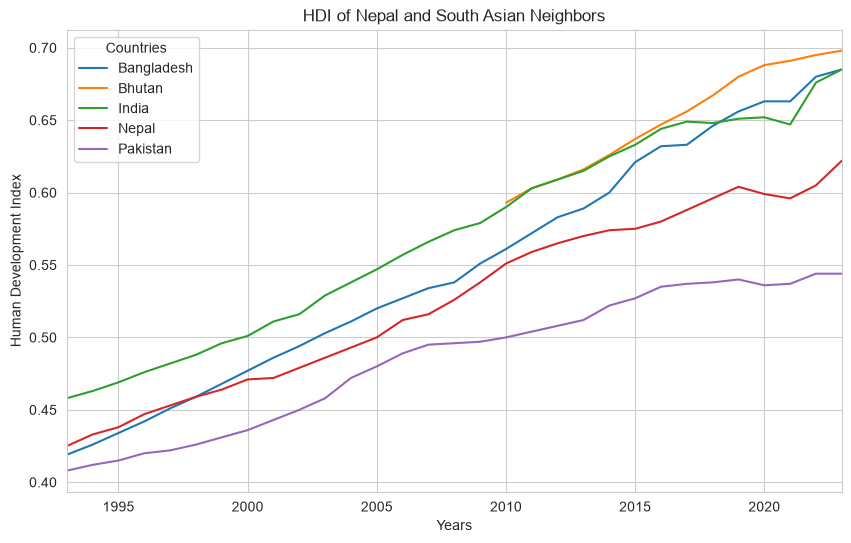

In [51]:
#plotting the hdi:
sns.set_style(style= 'whitegrid')
plt.figure(figsize=(10,6))
sns.lineplot(data=hdi_df, x = 'Year', y = 'HDI', hue='Country Name')
plt.title('HDI of Nepal and South Asian Neighbors')
plt.xlabel('Years')
plt.ylabel('Human Development Index')
plt.legend(title = 'Countries')
plt.xlim(1993,2023)
plt.show()

### Domestic Growth Indicators: Nepal vs Neighbors ###

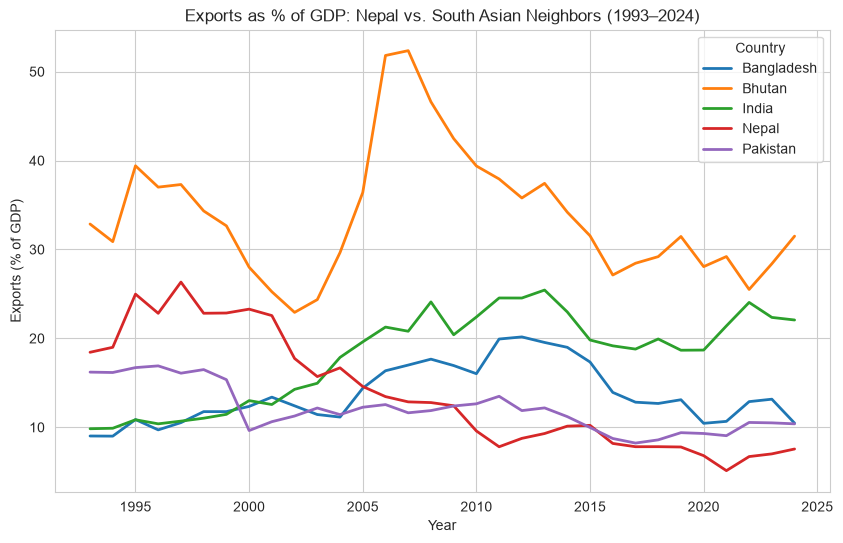

In [52]:
exports_df = long_df[long_df['Series Name'] == 'Exports of goods and services (% of GDP)']

plt.figure(figsize=(10,6))
sns.lineplot(data=exports_df, x='Year', y='value', hue='Country Name', linewidth=2)
plt.title("Exports as % of GDP: Nepal vs. South Asian Neighbors (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Exports (% of GDP)")
plt.legend(title='Country')
plt.show()

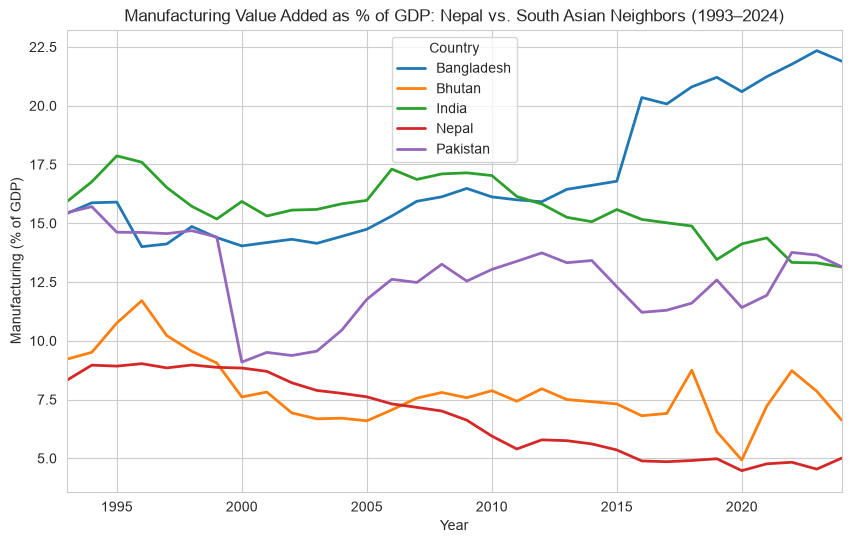

In [56]:
#Manufacturing value added:
manuf_df = long_df[long_df['Series Name'] == 'Manufacturing, value added (% of GDP)']

plt.figure(figsize=(10,6))
sns.lineplot(data=manuf_df, x='Year', y='value', hue='Country Name', linewidth=2)
plt.title("Manufacturing Value Added as % of GDP: Nepal vs. South Asian Neighbors (1993–2024)")
plt.xlim(1993,2024)
plt.xlabel("Year")
plt.ylabel("Manufacturing (% of GDP)")
plt.legend(title='Country')
plt.show()

In [54]:
long_df['Country Name']

0       Bangladesh
1           Bhutan
2            India
4            Nepal
7         Pakistan
           ...    
2040    Bangladesh
2041        Bhutan
2042         India
2044         Nepal
2047      Pakistan
Name: Country Name, Length: 1120, dtype: str

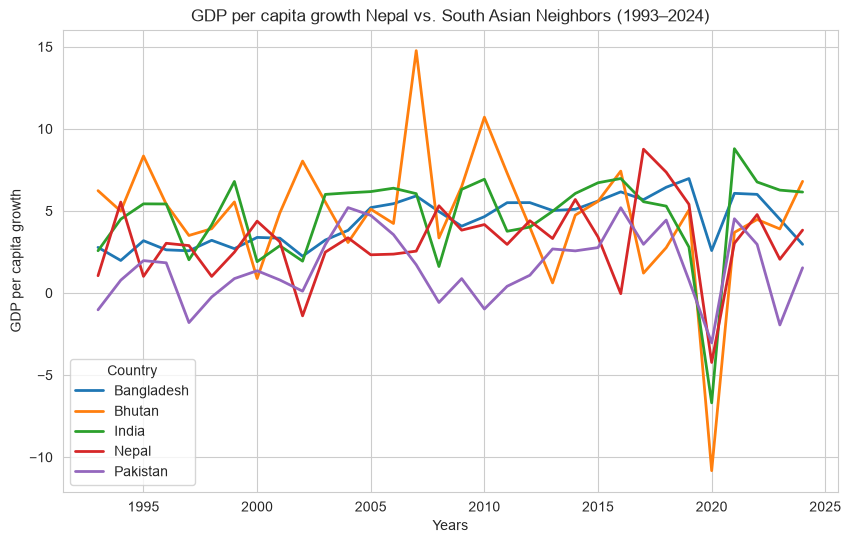

In [55]:
#gdp per capita growth
gdp_df = long_df[long_df['Series Name'] == 'GDP per capita growth (annual %)']

plt.figure(figsize=(10,6))
sns.lineplot(data=gdp_df, x='Year', y='value', hue='Country Name', linewidth=2)
plt.title("GDP per capita growth Nepal vs. South Asian Neighbors (1993–2024)")
plt.xlabel("Years")
plt.ylabel("GDP per capita growth")
plt.legend(title='Country')
plt.show()

## References ##

[*World Developent Indicators*]('https://databank.worldbank.org/source/world-development-indicators#')
[*Human Development Index Data*]()